# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Galih Permana Sidik
- Email: galihpermanar9@gmail.com
- Id Dicoding: cdcc596d6y2645

## Persiapan

### Menyiapkan library yang dibutuhkan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

import joblib
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

os.makedirs('model', exist_ok=True)

### Menyiapkan data yang akan digunakan

In [5]:
# Dataset: Students' Performance - Jaya Jaya Institut
# Sumber: https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Jaya Jaya Institut merupakan institusi pendidikan perguruan tinggi yang telah berdiri sejak tahun 2000. Hingga saat ini, Jaya Jaya Institut telah mencetak banyak lulusan dengan reputasi yang sangat baik. Namun, terdapat cukup banyak juga mahasiswa yang tidak menyelesaikan pendidikannya alias mengalami *dropout*.

Dataset yang digunakan berisi **4.424 baris data mahasiswa** dengan **36 fitur** (demografi, sosial-ekonomi, dan akademik) serta 1 kolom target `Status` yang menunjukkan status akhir mahasiswa: **Dropout**, **Enrolled**, atau **Graduate**.

In [6]:
print("Jumlah baris, kolom:", df.shape)
df.info()

Jumlah baris, kolom: (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification          

In [7]:
# Cek missing value dan duplikat
print("Total missing value:", df.isnull().sum().sum())
print("Total data duplikat:", df.duplicated().sum())

Total missing value: 0
Total data duplikat: 0


In [8]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [9]:
df['Status'].value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


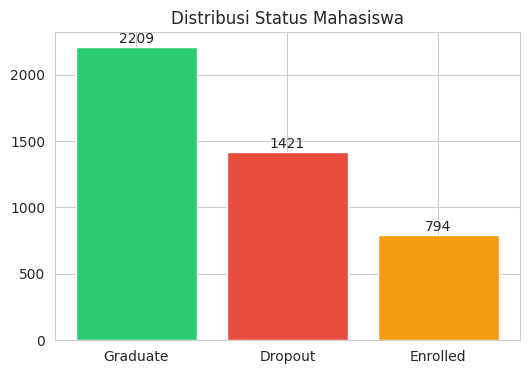

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
status_counts = df['Status'].value_counts()
ax.bar(status_counts.index, status_counts.values, color=['#2ecc71','#e74c3c','#f39c12'])
for i, v in enumerate(status_counts.values):
    ax.text(i, v+30, str(v), ha='center')
ax.set_title('Distribusi Status Mahasiswa')
plt.savefig('model/eda_status_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

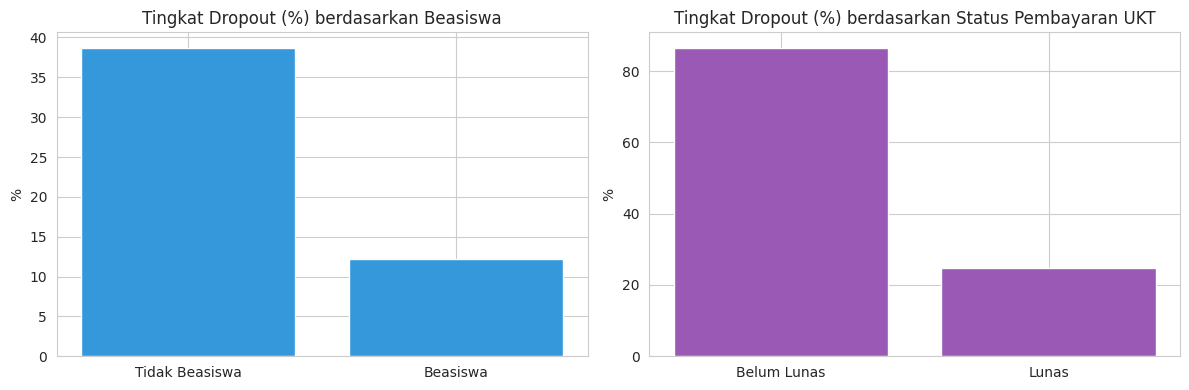

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sch = df.groupby('Scholarship_holder')['Status'].apply(lambda x: (x=='Dropout').mean()*100)
axes[0].bar(['Tidak Beasiswa','Beasiswa'], sch.values, color='#3498db')
axes[0].set_title('Tingkat Dropout (%) berdasarkan Beasiswa')
axes[0].set_ylabel('%')

tf = df.groupby('Tuition_fees_up_to_date')['Status'].apply(lambda x: (x=='Dropout').mean()*100)
axes[1].bar(['Belum Lunas','Lunas'], tf.values, color='#9b59b6')
axes[1].set_title('Tingkat Dropout (%) berdasarkan Status Pembayaran UKT')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.savefig('model/eda_scholarship_tuition.png', dpi=120, bbox_inches='tight')
plt.show()

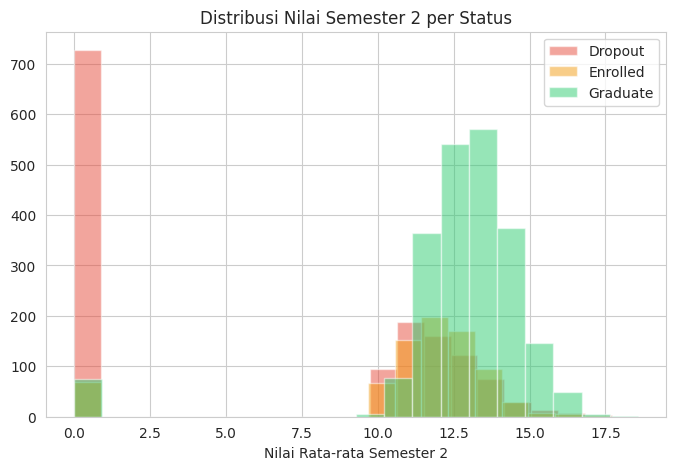

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
for status, c in zip(['Dropout','Enrolled','Graduate'], ['#e74c3c','#f39c12','#2ecc71']):
    sub = df[df['Status']==status]['Curricular_units_2nd_sem_grade']
    ax.hist(sub, bins=20, alpha=0.5, label=status, color=c)
ax.set_title('Distribusi Nilai Semester 2 per Status')
ax.set_xlabel('Nilai Rata-rata Semester 2')
ax.legend()
plt.savefig('model/eda_grade_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

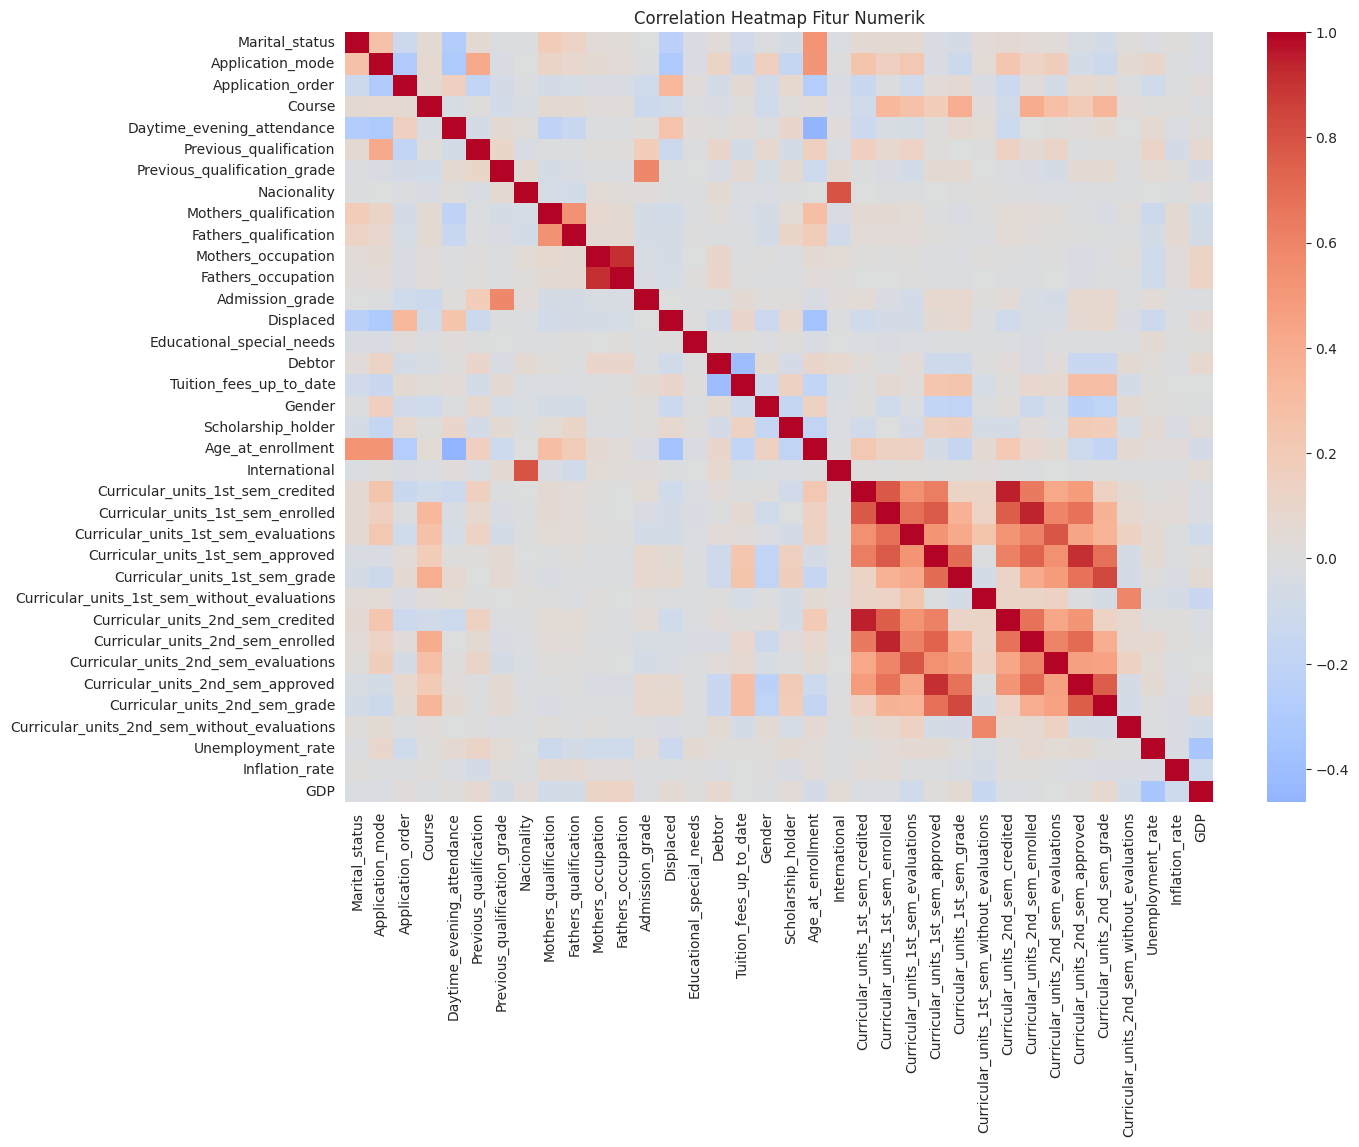

In [13]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap Fitur Numerik')
plt.savefig('model/eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight Data Understanding:**
- Dataset tidak memiliki *missing value* maupun data duplikat, sehingga siap digunakan tanpa proses cleaning berat.
- Target `Status` memiliki 3 kelas: **Graduate** (2.209 / 49,9%), **Dropout** (1.421 / 32,1%), **Enrolled** (794 / 17,9%) — terdapat sedikit ketidakseimbangan kelas.
- Mahasiswa **tanpa beasiswa** memiliki tingkat dropout (±38%) jauh lebih tinggi dibanding penerima beasiswa (±12%).
- Mahasiswa yang **belum melunasi UKT** memiliki tingkat dropout sangat tinggi (±86%) dibanding yang sudah lunas (±25%).
- Mahasiswa berstatus *Dropout* sebagian besar memiliki nilai semester 2 sebesar **0**, mengindikasikan mereka berhenti di tengah semester.

## Data Preparation / Preprocessing

In [14]:
X = df.drop(columns=['Status'])
y = df['Status']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Mapping label:", dict(zip(le.classes_, le.transform(le.classes_))))

feature_names = X.columns.tolist()

Mapping label: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (3539, 36) Test: (885, 36)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

In [17]:
model = RandomForestClassifier(
    n_estimators=300, max_depth=12, random_state=42, class_weight='balanced'
)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=300,
                       random_state=42)

## Evaluation

In [18]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.7570621468926554
F1-score (macro): 0.7030468280968581

              precision    recall  f1-score   support

     Dropout       0.83      0.70      0.76       284
    Enrolled       0.48      0.52      0.50       159
    Graduate       0.82      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



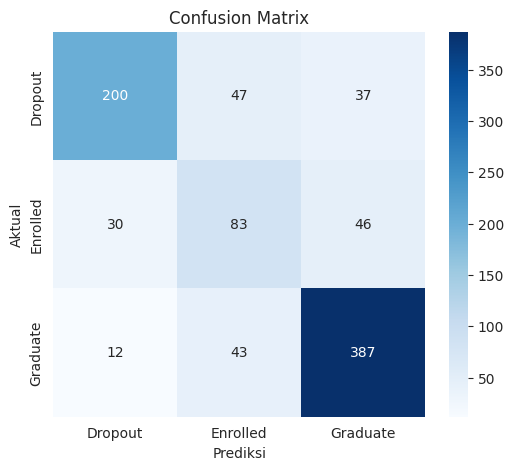

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.savefig('model/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

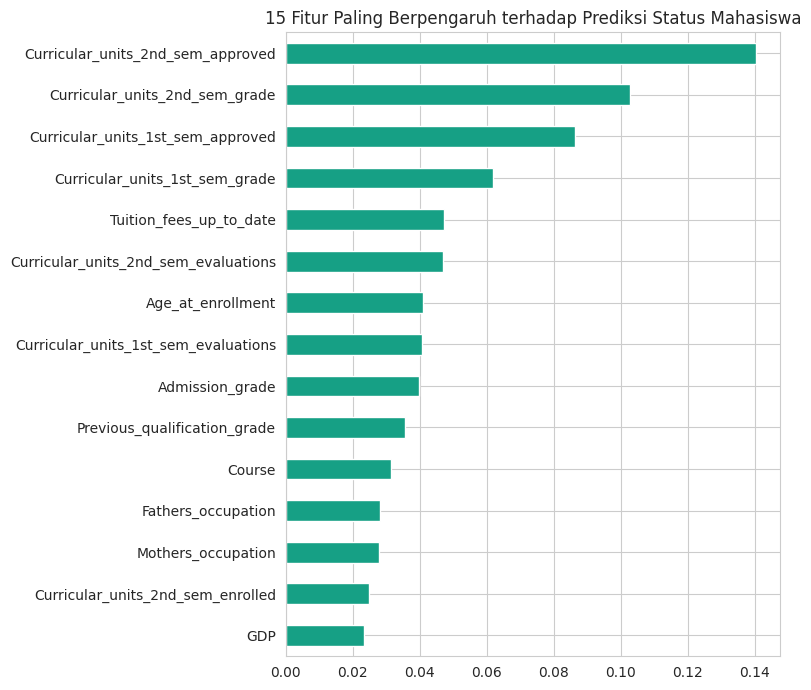

,0
Curricular_units_2nd_sem_approved,0.140585
Curricular_units_2nd_sem_grade,0.102718
Curricular_units_1st_sem_approved,0.086521
Curricular_units_1st_sem_grade,0.061785
Tuition_fees_up_to_date,0.047290
Curricular_units_2nd_sem_evaluations,0.046862
Age_at_enrollment,0.040846
Curricular_units_1st_sem_evaluations,0.040759
Admission_grade,0.039921
Previous_qualification_grade,0.035462


In [20]:
importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8,7))
importances.head(15).sort_values().plot(kind='barh', color='#16a085')
plt.title('15 Fitur Paling Berpengaruh terhadap Prediksi Status Mahasiswa')
plt.tight_layout()
plt.savefig('model/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
importances.head(15)

**Insight Evaluasi:**
- Model **Random Forest** menghasilkan akurasi ±76% dan F1-macro ±0,70 pada data uji.
- Performa terbaik pada kelas **Graduate** (F1 ±0,85) dan **Dropout** (F1 ±0,76), sedangkan kelas **Enrolled** paling sulit diprediksi (F1 ±0,50).
- Fitur paling berpengaruh: jumlah SKS lulus (`approved`) dan nilai (`grade`) semester 1 & 2, status pelunasan UKT, serta usia saat masuk.

### Menyimpan Model untuk Prototype

In [21]:
joblib.dump(model, 'model/model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(le, 'model/label_encoder.joblib')
joblib.dump(feature_names, 'model/feature_names.joblib')
print("Model, scaler, label encoder, dan feature_names berhasil disimpan di folder 'model/'")

Model, scaler, label encoder, dan feature_names berhasil disimpan di folder 'model/'


## Conclusion

Berdasarkan proses analisis data dan pemodelan machine learning yang telah dilakukan terhadap data mahasiswa Jaya Jaya Institut, dapat disimpulkan bahwa:

1. Tingkat dropout mahasiswa Jaya Jaya Institut cukup tinggi, yaitu **32,1%** dari total 4.424 mahasiswa pada dataset.
2. Faktor yang paling berkaitan dengan dropout antara lain: **status pelunasan UKT**, **jumlah SKS yang berhasil diselesaikan (approved)** dan **nilai** pada semester 1 & 2, **kepemilikan beasiswa**, serta **usia saat mendaftar**.
3. Mahasiswa yang belum melunasi UKT dan tidak memiliki beasiswa memiliki risiko dropout jauh lebih tinggi dibanding mahasiswa lainnya.
4. Model **Random Forest Classifier** yang dibangun mampu memprediksi status mahasiswa (Dropout/Enrolled/Graduate) dengan akurasi **±76%**, cukup andal digunakan sebagai alat bantu deteksi dini (early warning system) risiko dropout.
5. Model dan dashboard yang dihasilkan dapat digunakan pihak institusi untuk melakukan intervensi lebih awal kepada mahasiswa berisiko tinggi.

### Rekomendasi Action Items
- **Bangun sistem peringatan dini (early warning system)** menggunakan model prediksi ini, dijalankan setiap akhir semester untuk mengidentifikasi mahasiswa berisiko dropout tinggi, agar tim akademik dapat segera melakukan intervensi.
- **Evaluasi kembali program beasiswa dan skema pembayaran UKT** (misalnya cicilan atau keringanan bagi mahasiswa kurang mampu), mengingat status pelunasan UKT dan beasiswa sangat berkorelasi dengan dropout.
- **Lakukan monitoring performa akademik secara berkala** (jumlah SKS disetujui dan nilai per semester) melalui dashboard, terutama pada mahasiswa dengan performa menurun drastis di semester berjalan.
- **Berikan perhatian khusus pada mahasiswa usia non-tradisional** (lebih tua saat mendaftar) karena kelompok ini menunjukkan risiko dropout lebih tinggi berdasarkan feature importance.
- **Lakukan survei/wawancara terhadap mahasiswa berisiko tinggi** untuk memahami akar masalah non-akademik (finansial, keluarga, kesehatan mental) sebagai pelengkap data kuantitatif.
- **Integrasikan model prediksi ke dalam sistem informasi akademik** agar dosen wali/pembimbing akademik dapat mengakses skor risiko dropout mahasiswa bimbingannya secara real-time.